# Sleep-EDF: explore the five-stage task

Use **Sleep-EDF Expanded 1.0.0**, the **Sleep Cassette** cohort: 78 participants and
153 nights. Source: [PhysioNet](https://physionet.org/content/sleep-edfx/1.0.0/).
License: Open Data Commons Attribution License v1.0. Exclude the separate
Sleep Telemetry medication study.

This notebook prepares proposal evidence: annotation counts, a participant split,
and a one-epoch signal/spectrogram preview. Counts remain preliminary until the
EEG recordings pass boundary and signal-quality checks. Instructor approval of
EEG spectrograms under the image-classification category is still required.

Install from the repository root: `python3 -m pip install -r A2/requirements-sleep.txt`.
Select that Python environment as the notebook kernel and run the cells in order.
Existing files in `A2/sleep-cassette` are reused. Missing small annotation files
are downloaded to `A2/sleep_exploration/annotations`; PSG recordings are not downloaded.


In [5]:
import sys
!{sys.executable} pip install numpy>=1.24,<3 scipy>=1.10,<2 mne>=1.6,<2 torch>=2,<3 scikit-learn>=1.9.1,<2 pandas>=2,<3 matplotlib>=3.7,<4 ipykernel>=6,<8


/bin/bash: line 1: 3: No such file or directory


In [6]:
%pip install "numpy>=1.24,<3" "scipy>=1.10,<2" "mne>=1.6,<2" "torch>=2,<3" "scikit-learn>=1.9.1,<2" "pandas>=2,<3" "matplotlib>=3.7,<4" "ipykernel>=6,<8"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 68.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 90.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 93.2 MB/s eta 0:00:00:00:01
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [7]:
from pathlib import Path
import hashlib
import json
import random
from urllib.request import urlopen

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from sklearn.model_selection import StratifiedGroupKFold
import sklearn

base_dir = Path.cwd()
if (base_dir / "A2").is_dir():
    base_dir = base_dir / "A2"
output_dir = base_dir / "sleep_exploration"
output_dir.mkdir(exist_ok=True)

stage_names = ["W", "N1", "N2", "N3", "REM"]
stage_map = {
    "Sleep stage W": 0,
    "Sleep stage 1": 1,
    "Sleep stage 2": 2,
    "Sleep stage 3": 3,
    "Sleep stage 4": 3,
    "Sleep stage R": 4,
}
epoch_seconds = 30
wake_margin = 30 * 60
source_url = "https://physionet.org/files/sleep-edfx/1.0.0/"


## Pair recordings and annotations

`SC4001E0-PSG.edf` contains the signals; `SC4001EC-Hypnogram.edf` contains the
expert labels. Match the **first six characters** to identify a night, because
the final characters differ. The **first five characters** identify a participant:
both nights of `SC400` must stay in one split.

Verify downloaded annotation files against the published checksums. An incomplete
file in the original download directory is left untouched; a verified copy is
cached separately. The official checksum manifest defines the full cohort even
while the larger PSG files are still downloading.


In [8]:
manifest_path = base_dir / "SHA256SUMS.txt"
if not manifest_path.exists():
    manifest_path.write_bytes(urlopen(source_url + "SHA256SUMS.txt", timeout=30).read())
checksums = {}
for line in manifest_path.read_text().splitlines():
    checksum, name = line.split(maxsplit=1)
    checksums[name] = checksum

annotation_names = sorted(
    name for name in checksums
    if name.startswith("sleep-cassette/") and name.endswith("-Hypnogram.edf")
)
psg_names = {
    Path(name).name[:6]: name for name in checksums
    if name.startswith("sleep-cassette/") and name.endswith("-PSG.edf")
}
assert len(annotation_names) == len(psg_names) == 153


def verified(path, checksum):
    return path.is_file() and hashlib.sha256(path.read_bytes()).hexdigest() == checksum


annotation_paths = []
for name in annotation_names:
    path = base_dir / name
    if not verified(path, checksums[name]):
        path = output_dir / "annotations" / Path(name).name
        path.parent.mkdir(exist_ok=True)
        if not verified(path, checksums[name]):
            content = urlopen(source_url + name, timeout=30).read()
            assert hashlib.sha256(content).hexdigest() == checksums[name], name
            path.write_bytes(content)
    annotation_paths.append(path)

print(f"Verified {len(annotation_paths)} hypnograms.")
print(f"PSG files currently present: {sum((base_dir / p).is_file() for p in psg_names.values())}/153")
print("File presence alone does not verify that a PSG download is complete.")


Verified 153 hypnograms.
PSG files currently present: 0/153
File presence alone does not verify that a PSG download is complete.


## Count 30-second epochs

Map W / 1 / 2 / 3+4 / R to W / N1 / N2 / N3 / REM. Discard movement and unscored
intervals. Keep the period from 30 minutes before the first scored sleep interval
through 30 minutes after the last scored sleep interval. This limits long daytime
wake periods while retaining wake during the night.

Count complete 30-second epochs on the original annotation grid. Do not count
annotation rows as samples: one row can describe many minutes of the same stage.
This is an annotation audit; full PSG duration and artifact checks come later.


In [9]:
rows = []
for path in annotation_paths:
    annotations = mne.read_annotations(path)
    sleep = [a for a in annotations if a["description"] in stage_map
             and a["description"] != "Sleep stage W"]
    assert sleep, f"No scored sleep in {path.name}"
    first = max(0, min(a["onset"] for a in sleep) - wake_margin)
    last = max(a["onset"] + a["duration"] for a in sleep) + wake_margin

    for annotation in annotations:
        description = annotation["description"]
        if description not in stage_map:
            continue
        onset = annotation["onset"]
        end = onset + annotation["duration"]
        for start in np.arange(onset, end, epoch_seconds):
            if start < first or start + epoch_seconds > min(end, last):
                continue
            label = stage_map[description]
            rows.append({"participant": path.name[:5], "recording": path.name[:6],
                         "onset": start, "label": label, "stage": stage_names[label]})

epochs = pd.DataFrame(rows)
assert epochs["participant"].nunique() == 78
assert epochs["recording"].nunique() == 153
counts = epochs["stage"].value_counts().reindex(stage_names)
distribution = pd.DataFrame({"epochs": counts, "percent": (100 * counts / counts.sum()).round(2)})
distribution.to_csv(output_dir / "class_distribution.csv")
print(distribution.to_string())
print(f"Total: {len(epochs):,} candidate epochs")


       epochs  percent
stage                 
W       65941    33.73
N1      21522    11.01
N2      69132    35.37
N3      13039     6.67
REM     25835    13.22
Total: 195,469 candidate epochs


## Stratified group cross-validation with an untouched test set

Keep the same 12 test participants. Combine the other 66 into a development set
and apply **5-fold StratifiedGroupKFold** with participant IDs as groups and the
five sleep-stage labels as `y`. Each development participant is in validation
exactly once, and training in the other four folds. Group membership takes
priority over exact class proportions, so balance is approximate.

Ordinary StratifiedKFold on epochs would allow the same person's nights and
adjacent epochs into both training and validation. Each participant has multiple
stage labels, so assigning one stage label to each person is also inappropriate.

Reinitialize the model and optimizer in each fold. Fit normalization and class
weights using that fold's training participants only. Select settings by mean
validation macro-F1 across the five folds. Then refit on all 66 development
participants, using a training duration chosen from cross-validation, and evaluate
the fixed test set. Fold standard deviation describes variability, not a confidence
interval from five independent experiments.

Use the saved participant fold manifest for training. It records each development
participant's validation fold (1–5); test participants have fold -1. A training mask
must require `split == "development"` as well as `validation_fold != fold`.
[Official scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html).


In [10]:
# Preserve the original 12 test participants; use everyone else for cross-validation.
participants = sorted(epochs["participant"].unique())
random.Random(42).shuffle(participants)
test_participants = set(participants[66:])
epochs["split"] = np.where(epochs["participant"].isin(test_participants), "test", "development")
development = epochs[epochs["split"] == "development"].copy()

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
y = development["label"].to_numpy()
groups = development["participant"].to_numpy()
validation_fold = {}
fold_rows = []
class_rows = []

# No EEG features are needed to choose folds: only labels and participant IDs.
for fold, (train_idx, val_idx) in enumerate(cv.split(np.zeros((len(y), 1)), y, groups), start=1):
    train = development.iloc[train_idx]
    validation = development.iloc[val_idx]
    train_people = set(train["participant"])
    val_people = set(validation["participant"])
    assert train_people.isdisjoint(val_people)
    assert (train_people | val_people).isdisjoint(test_participants)
    assert val_people.isdisjoint(validation_fold)
    assert len(train) >= 5000
    assert train["label"].nunique() == validation["label"].nunique() == 5
    validation_fold.update({person: fold for person in val_people})
    fold_rows.append({"fold": fold, "train_participants": len(train_people),
                      "validation_participants": len(val_people),
                      "train_epochs": len(train), "validation_epochs": len(validation)})
    for name, subset in [("train", train), ("validation", validation)]:
        stage_counts = subset["stage"].value_counts().reindex(stage_names, fill_value=0)
        class_rows.append({"fold": fold, "split": name, **stage_counts.to_dict()})

assert set(validation_fold) == set(development["participant"])
epochs["validation_fold"] = epochs["participant"].map(validation_fold).fillna(-1).astype(int)
fold_summary = pd.DataFrame(fold_rows).set_index("fold")
fold_summary.to_csv(output_dir / "cv_fold_summary.csv")
pd.DataFrame(class_rows).to_csv(output_dir / "cv_class_counts.csv", index=False)
participant_split = epochs[["participant", "split"]].drop_duplicates().sort_values("participant")
participant_split.to_csv(output_dir / "participant_split.csv", index=False)
participant_folds = epochs[["participant", "split", "validation_fold"]].drop_duplicates().sort_values("participant")
participant_folds.to_csv(output_dir / "cv_folds.csv", index=False)

split_counts = pd.crosstab(epochs["split"], epochs["stage"]).reindex(
    index=["development", "test"], columns=stage_names, fill_value=0)
split_counts["total"] = split_counts.sum(axis=1)
split_counts.to_csv(output_dir / "split_counts.csv")
night_counts = epochs.groupby(["participant", "recording", "split", "stage"]).size().unstack(fill_value=0)
night_counts.reindex(columns=stage_names).to_csv(output_dir / "night_counts.csv")
metadata = {"method": "StratifiedGroupKFold", "n_splits": 5, "shuffle": True,
            "random_state": 42, "sklearn_version": sklearn.__version__,
            "test_participants": sorted(test_participants)}
(output_dir / "cv_metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
print(split_counts.to_string())
print("\n" + fold_summary.to_string())


stage            W     N1     N2     N3    REM   total
split                                                 
development  59966  19441  58754  10529  21847  170537
test          5975   2081  10378   2510   3988   24932

      train_participants  validation_participants  train_epochs  validation_epochs
fold                                                                              
1                     53                       13        137438              33099
2                     53                       13        136763              33774
3                     53                       13        136914              33623
4                     52                       14        136026              34511
5                     53                       13        135007              35530


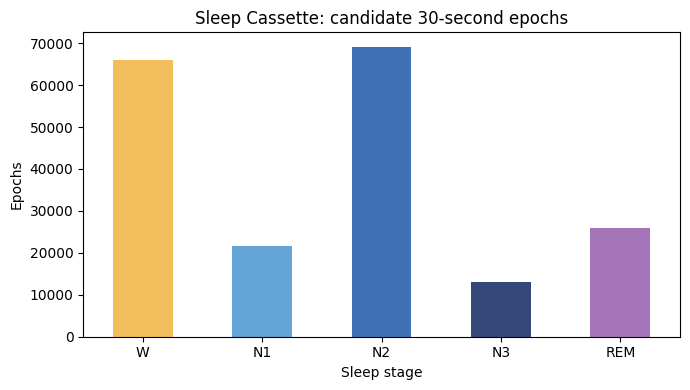

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
counts.plot.bar(ax=ax, color=["#f2be5c", "#64a5d8", "#4070b6", "#344879", "#a575b9"])
ax.set(title="Sleep Cassette: candidate 30-second epochs", xlabel="Sleep stage", ylabel="Epochs")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(output_dir / "class_distribution.png", dpi=150)
plt.show()


## Preview one epoch from a verified PSG

Use the first available complete recording and a labelled N2 epoch. EEG channels
Fpz-Cz and Pz-Oz are sampled at 100 Hz. The preview reads only that 30-second slice.
It does not filter the signal or fit normalization: it illustrates the proposed
log-PSD representation before full preprocessing is implemented.

A two-second Hann window and 0.5-second hop yield 57 time bins; retaining 0.5–30 Hz
yields 60 frequency bins. One example therefore has shape **(2, 60, 57)**.


In [12]:
psg_path = None
for recording, name in sorted(psg_names.items()):
    candidate = base_dir / name
    if verified(candidate, checksums[name]):
        psg_path = candidate
        break
assert psg_path is not None, "Finish downloading at least one PSG before this preview."

channels = ["EEG Fpz-Cz", "EEG Pz-Oz"]
raw = mne.io.read_raw_edf(psg_path, include=channels, preload=False, verbose="ERROR")
raw.reorder_channels(channels)
sfreq = raw.info["sfreq"]
assert sfreq == 100
night_epochs = epochs[epochs["recording"] == recording]
selected = night_epochs[night_epochs["stage"] == "N2"].iloc[0]
start = round(selected["onset"] * sfreq)
stop = start + round(epoch_seconds * sfreq)
assert stop <= raw.n_times, "Selected annotation extends beyond this PSG."
eeg = raw.get_data(start=start, stop=stop) * 1e6

frequencies, times, power = spectrogram(
    eeg, fs=sfreq, window="hann", nperseg=200, noverlap=150,
    detrend=False, scaling="density", mode="psd", axis=-1)
keep = (frequencies >= 0.5) & (frequencies <= 30)
patch = np.log10(np.maximum(power[:, keep, :], 1e-12)).astype(np.float32)
assert patch.shape == (2, 60, 57) and np.isfinite(patch).all()
print(psg_path.name, "stage:", selected["stage"], "patch:", patch.shape)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
axes[0].plot(np.arange(eeg.shape[1]) / sfreq, eeg[0], lw=0.7, color="#4070b6")
axes[0].set(title=f"{recording}: 30 seconds of N2, Fpz-Cz", xlabel="Seconds", ylabel="µV")
im = axes[1].pcolormesh(times, frequencies[keep], patch[0], shading="auto", cmap="magma")
axes[1].set(xlabel="Seconds", ylabel="Frequency (Hz)", title="Log-PSD preview")
fig.colorbar(im, ax=axes[1], label="log10(µV²/Hz)")
fig.tight_layout()
fig.savefig(output_dir / "epoch_preview.png", dpi=150)
plt.show()
raw.close()


AssertionError: Finish downloading at least one PSG before this preview.

## Proposed next steps after dataset approval

1. Verify full PSG downloads, channel names, sampling rates, timing alignment,
   and every retained epoch against the recording length.
2. Process one night at a time; use documented filtering and quality rules,
   the same five-stage mapping, and the frozen participant/fold manifests.
3. Convert each complete 30-second epoch to a log-PSD patch. Save `patches`
   (float32), `labels` (int64), `groups` (participant IDs), recording IDs, and onsets
   in `.pt` files. Shards per recording avoid stacking the entire cohort in RAM.
4. Compare relative band-power + logistic regression, a small CNN, and an
   ImageNet-pretrained ResNet-18 with its first layer adapted to two channels.
5. Compare models using mean and standard deviation of validation macro-F1 over
   five folds. After selection, refit on all development participants and evaluate
   the untouched test participants. Report macro-F1, balanced accuracy, Cohen's
   kappa, per-stage recall, a confusion matrix, and participant-level variability.

The wake-trimming rule uses expert sleep labels to define a retrospective benchmark.
It does not establish performance on an untrimmed overnight recording in deployment.
The original annotations use Rechtschaffen–Kales stages; merging 3 and 4 is a
five-class conversion, not a claim that the recordings were rescored under AASM.

References: [Sleep-EDF dataset](https://physionet.org/content/sleep-edfx/1.0.0/),
[MNE sleep tutorial](https://mne.tools/stable/auto_tutorials/clinical/60_sleep.html).
